In [67]:
import warnings
warnings.filterwarnings("ignore")

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc

import scvi
import torch
import matplotlib.pyplot as plt
import anndata as ad
import scipy.sparse as sp
import spVIPESmulti

import seaborn as sns
from pathlib import Path

np.random.seed(0)
torch.manual_seed(0)
sc.settings.set_figure_params(dpi=80, frameon=False)

print(f"spVIPESmulti  : {spVIPESmulti.__version__}")
print(f"scvi-tools: {scvi.__version__}")
print(f"scanpy   : {sc.__version__}")
print(f"torch    : {torch.__version__} (CUDA available: {torch.cuda.is_available()})")
print(f"anndata  : {ad.__version__}")

spVIPESmulti  : 1.0.0
scvi-tools: 1.4.2
scanpy   : 1.12.1
torch    : 2.11.0+cu128 (CUDA available: True)
anndata  : 0.12.11


In [2]:
root = Path("/exports/para-lipg-hpc/mdmanurung/spVIPESmulti/docs/notebooks/")
path_obs = root/"data/bcells_obs.csv"
path_rna = root/"data/bcells_rna.csv"

In [3]:
adata = ad.read_csv(path_rna, first_column_names=True)
obs = pd.read_csv(path_obs, index_col=0)
adata.obs = obs
adata.layers["counts"] = adata.X.copy()

In [4]:
adata

AnnData object with n_obs × n_vars = 20761 × 38605
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'nCount_HTO', 'nFeature_HTO', 'batch', 'cellhashr_id', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_hemo', 'scdblfinder_score', 'scdblfinder_class', 'scran_size_factors', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'clonalProportion', 'clonalFrequency', 'cloneSize', 'barcode', 'IGH', 'cdr3_aa1', 'cdr3_nt1', 'IGLC', 'cdr3_nt2', 'has_bcr', 'NANP', 'NJunction', 'qc_keep', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'seurat_clusters', 'MG_nn_res.0.1', 'MG_res.0.1', 'MG_nn_res.0.2', 'MG_res.0.2', 'MG_nn_res.0.3', 'MG_res.0.3', 'MG_nn_res.0.4', 'MG_res.0.4', 'MG_nn_res.0.5', 'MG_res.0.5', 'MG_nn_res.0.6', 'MG_res.0.6', 'MG_nn_res.0.7', 'MG_res.0.7', 'MG_nn_res.0.8', 'MG_res.0.8', 'MG_nn_res.0.9', 'MG_res.0.9', 'MG_nn_res.1', 'MG_res.1', 'MG_nn_res.1.1', 'MG_res.1.1', 'MG_nn_res.1.2', 'MG_res.1.2', 'MG_nn_res.1.3', 'MG_res.1.3', 

In [5]:
print("\n".join(adata.obs.columns))

nCount_RNA
nFeature_RNA
nCount_ADT
nFeature_ADT
nCount_HTO
nFeature_HTO
batch
cellhashr_id
percent_mito
percent_ribo
percent_mito_ribo
log10GenesPerUMI
percent_top50
percent_hemo
scdblfinder_score
scdblfinder_class
scran_size_factors
CTgene
CTnt
CTaa
CTstrict
clonalProportion
clonalFrequency
cloneSize
barcode
IGH
cdr3_aa1
cdr3_nt1
IGLC
cdr3_nt2
has_bcr
NANP
NJunction
qc_keep
RNA.weight
ADT.weight
wsnn_res.1
seurat_clusters
MG_nn_res.0.1
MG_res.0.1
MG_nn_res.0.2
MG_res.0.2
MG_nn_res.0.3
MG_res.0.3
MG_nn_res.0.4
MG_res.0.4
MG_nn_res.0.5
MG_res.0.5
MG_nn_res.0.6
MG_res.0.6
MG_nn_res.0.7
MG_res.0.7
MG_nn_res.0.8
MG_res.0.8
MG_nn_res.0.9
MG_res.0.9
MG_nn_res.1
MG_res.1
MG_nn_res.1.1
MG_res.1.1
MG_nn_res.1.2
MG_res.1.2
MG_nn_res.1.3
MG_res.1.3
MG_nn_res.1.4
MG_res.1.4
MG_nn_res.1.5
MG_res.1.5
MG_nn_res.1.6
MG_res.1.6
MG_nn_res.1.7
MG_res.1.7
MG_nn_res.1.8
MG_res.1.8
MG_nn_res.1.9
MG_res.1.9
MG_nn_res.2
MG_res.2
MG_nn_res.2.1
MG_res.2.1
MG_nn_res.2.2
MG_res.2.2
MG_nn_res.2.3
MG_res.2.3
MG_nn_

In [6]:
adata.obs["subject_id"].value_counts()

subject_id
GA0817    6314
GA1160    3896
GA0746    3793
GA0825    3402
GA0888    2128
GA1333    1214
Name: count, dtype: int64

In [7]:
adata.obs["batch"].value_counts()

batch
batch3    9132
batch2    6333
batch1    5296
Name: count, dtype: int64

In [8]:
adata.obs["day"].value_counts()

day
T5    3853
T7    3400
T3    3390
T4    3311
T6    2908
T2    2274
T1    1611
Name: count, dtype: int64

In [9]:
adata.obs["cluster_label"].value_counts()

cluster_label
Naïve              5671
Classical          3531
Atypical           3389
Activated          2612
Transitional       2278
Pre-Plasmablast    1725
Activated MZ       1028
Plasmablast         527
Name: count, dtype: int64

In [10]:
adata.obs["antigen_specific"].value_counts()

antigen_specific
Negative    10783
CRXV         6898
NANP         2207
Njunc         873
Name: count, dtype: int64

In [11]:
adata.obs["antigen_class"] = (
    adata.obs["antigen_specific"]
    .astype(str)
    .str.strip()
    .apply(lambda x: "Negative" if x.lower() == "negative" else "Positive")
)
adata.obs["antigen_class"].value_counts()

antigen_class
Negative    10783
Positive     9978
Name: count, dtype: int64

In [12]:
sc.pp.highly_variable_genes(adata, n_top_genes=5000, flavor="seurat_v3", batch_key="batch")
adata = adata[:, adata.var["highly_variable"]].copy()

In [13]:
# Split into per-time-point AnnData objects
antigen_class = sorted(adata.obs["antigen_class"].unique())
adatas_dict = {}
for ac in antigen_class:
    sub = adata[adata.obs["antigen_class"] == ac].copy()
    # Clean up — prepare_adatas doesn't need extra obsm/uns
    sub.uns = {}
    sub.obsm = {}
    sub.layers = {}
    adatas_dict[ac] = sub
    print(f"  {ac}: {sub.shape}")

# Concatenate with spVIPESmulti
adata_spv = spVIPESmulti.data.prepare_adatas(adatas_dict)

print(f"\nConcatenated AnnData: {adata_spv.shape}")
print(f"Groups             : {list(adata_spv.uns['groups_mapping'].values())}")
print(f"Group sizes        : {[len(g) for g in adata_spv.uns['groups_obs_indices']]}")

  Negative: (10783, 5000)
  Positive: (9978, 5000)

Concatenated AnnData: (20761, 10000)
Groups             : ['Negative', 'Positive']
Group sizes        : [10783, 9978]


In [14]:
spVIPESmulti.model.spVIPESmulti.setup_anndata(
    adata_spv,
    groups_key="groups",
    label_key="cluster_label",
    batch_key="batch"
)

INFO     spVIPESmulti: === spVIPESmulti AnnData Setup ===                                                          
INFO     spVIPESmulti: Setting up with groups_key: 'groups'                                                        
INFO     spVIPESmulti: Labels: Using 'cluster_label' from adata.obs                                                
INFO     spVIPESmulti: --- Product of Experts (PoE) Configuration ---                                              
INFO     spVIPESmulti: Will use: Label-based PoE                                                                   


In [15]:
# Model hyperparameters
N_SHARED   = 16
N_PRIVATE  = 8
N_HIDDEN   = 128
DROPOUT    = 0.1
MAX_EPOCHS = 150
BATCH_SIZE = 256
KL_WARMUP  = 20


model_spv = spVIPESmulti.model.spVIPESmulti(
    adata_spv,
    n_hidden=N_HIDDEN,
    n_dimensions_shared=N_SHARED,
    n_dimensions_private=N_PRIVATE,
    dropout_rate=DROPOUT,
    disentangle_preset="no_contrastive",
    # use_nf_prior=True,
    # nf_type="NSF",               # "NSF" or "MAF"
    # nf_transforms=3,
    # nf_target="both",          # "shared", "private", or "both"
)

INFO     spVIPESmulti: The model has been initialized                                                              


In [93]:
[len(g) for g in group_indices_list]

[10783, 9978]

In [16]:
# Get group indices from uns (canonical approach matching prepare_adatas output)
group_indices_list = [list(map(int, g)) for g in adata_spv.uns["groups_obs_indices"]]
print("Group sizes:", [len(g) for g in group_indices_list])

# Train
model_spv.train(
    group_indices_list,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    train_size=0.9,
    early_stopping=True,
    n_epochs_kl_warmup=KL_WARMUP,
)


Group sizes: [10783, 9978]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 150/150: 100%|██████████| 150/150 [11:47<00:00,  5.19s/it, v_num=1, train_loss=1.44e+3]

`Trainer.fit` stopped: `max_epochs=150` reached.


Epoch 150/150: 100%|██████████| 150/150 [11:47<00:00,  4.72s/it, v_num=1, train_loss=1.44e+3]


In [22]:
model_spv.save("docs/notebooks/results/spvipes_bcells")

In [94]:
[len(g) for g in group_indices_list]

[10783, 9978]

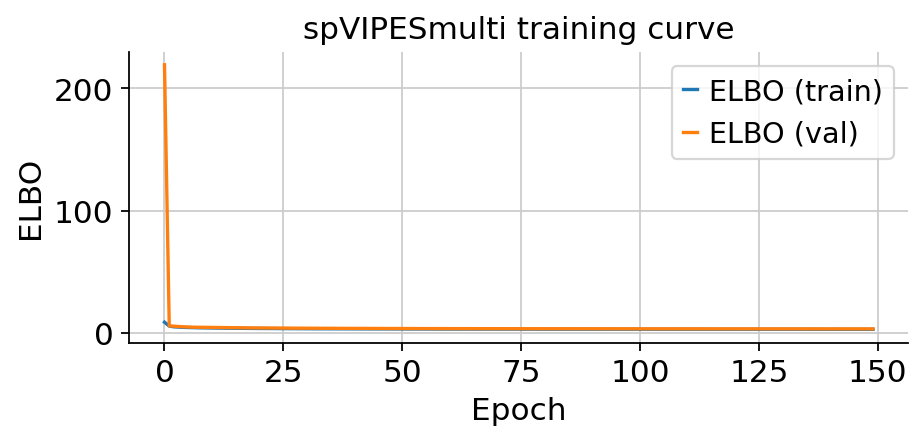

In [20]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(model_spv.history["elbo_train"]["elbo_train"], label="ELBO (train)")
if "elbo_validation" in model_spv.history:
    ax.plot(model_spv.history["elbo_validation"]["elbo_validation"], label="ELBO (val)")
ax.set_xlabel("Epoch")
ax.set_ylabel("ELBO")
ax.set_title("spVIPESmulti training curve")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

In [24]:
payload = model_spv.embed(batch_size=1024)
# payload["keys"]["shared"] == "X_spvm_shared"

In [27]:
payload["keys"]["shared"]

'X_spvm_shared'

In [31]:
group_indices_list = [list(map(int, g)) for g in adata_spv.uns["groups_obs_indices"]]
latents = model_spv.get_latent_representation(group_indices_list, batch_size=512)
spVIPESmulti.utils.store_latents(adata_spv, latents, group_indices_list)

AnnData object with n_obs × n_vars = 20761 × 10000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'nCount_HTO', 'nFeature_HTO', 'batch', 'cellhashr_id', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_hemo', 'scdblfinder_score', 'scdblfinder_class', 'scran_size_factors', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'clonalProportion', 'clonalFrequency', 'cloneSize', 'barcode', 'IGH', 'cdr3_aa1', 'cdr3_nt1', 'IGLC', 'cdr3_nt2', 'has_bcr', 'NANP', 'NJunction', 'qc_keep', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'seurat_clusters', 'MG_nn_res.0.1', 'MG_res.0.1', 'MG_nn_res.0.2', 'MG_res.0.2', 'MG_nn_res.0.3', 'MG_res.0.3', 'MG_nn_res.0.4', 'MG_res.0.4', 'MG_nn_res.0.5', 'MG_res.0.5', 'MG_nn_res.0.6', 'MG_res.0.6', 'MG_nn_res.0.7', 'MG_res.0.7', 'MG_nn_res.0.8', 'MG_res.0.8', 'MG_nn_res.0.9', 'MG_res.0.9', 'MG_nn_res.1', 'MG_res.1', 'MG_nn_res.1.1', 'MG_res.1.1', 'MG_nn_res.1.2', 'MG_res.1.2', 'MG_nn_res.1.3', 'MG_res.1.3', 

In [ ]:
# Shared latent UMAP (all groups integrated):
spVIPESmulti.utils.compute_shared_umap(adata_spv)

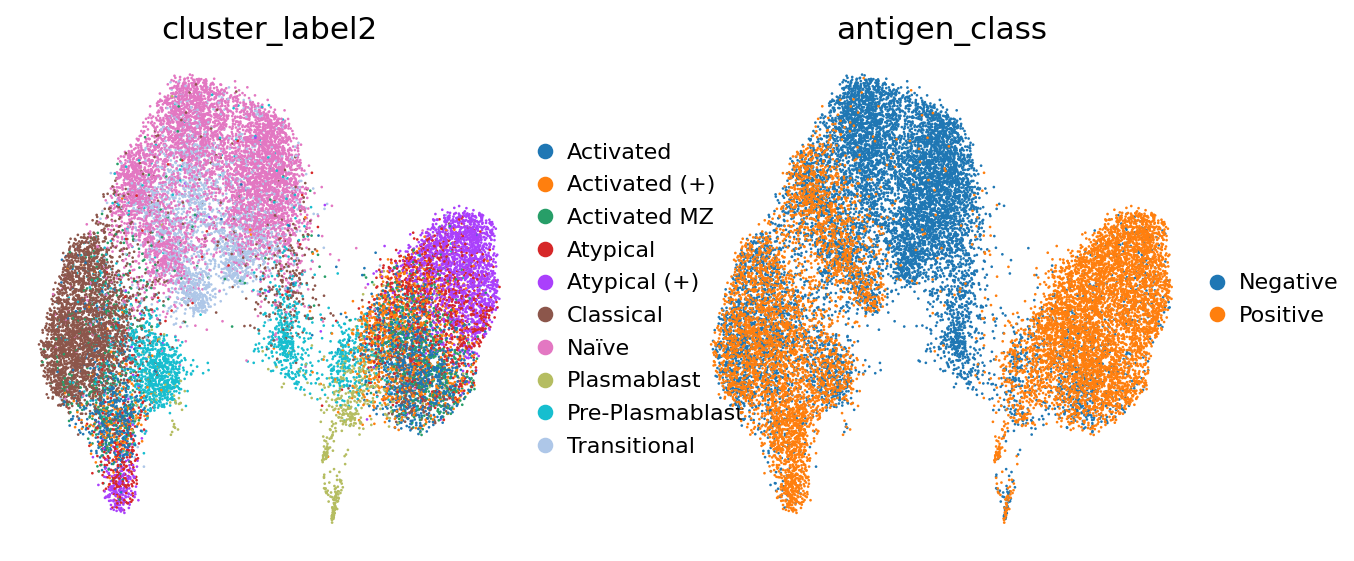

In [60]:
spVIPESmulti.pl.umap_shared(adata_spv, color=["cluster_label2", "antigen_class"])

In [34]:
# Top genes per shared latent dimension:
top = spVIPESmulti.utils.get_top_genes(model=model_spv, n_top=10)
print(top[["dim", "pos_genes"]].to_string(index=False))

        dim                                                                                                                                                                                     pos_genes
 Z_shared_0 [Negative_MIR181A1HG, Negative_SEMA4A, Negative_ADAM23, Negative_BHLHA15, Negative_IGKV1-8, Negative_CD38, Negative_ENSG00000257275, Negative_CPM, Negative_ENSG00000290072, Negative_SLC1A4]
 Z_shared_1         [Negative_IGKV1-12, Negative_NBPF26, Negative_H2AC13, Negative_IGKV3-7, Negative_COL4A3, Negative_IGHV3-49, Negative_IGKV1-33, Negative_BEX5, Negative_ENSG00000189229, Negative_TK1]
 Z_shared_2                       [Negative_NBPF26, Negative_MME, Negative_AK8, Negative_ENSG00000286581, Negative_HRK, Negative_ALKAL2, Negative_AIRE, Negative_SPINK2, Negative_FUT7, Negative_PLA2G2D]
 Z_shared_3              [Negative_IGKV1-8, Negative_IGKV1-12, Negative_HOPX, Negative_LCP2, Negative_TOX-DT, Negative_IGKV3-7, Negative_IGF2BP3, Negative_ENSG00000289137, Negative_TOX2, Negat

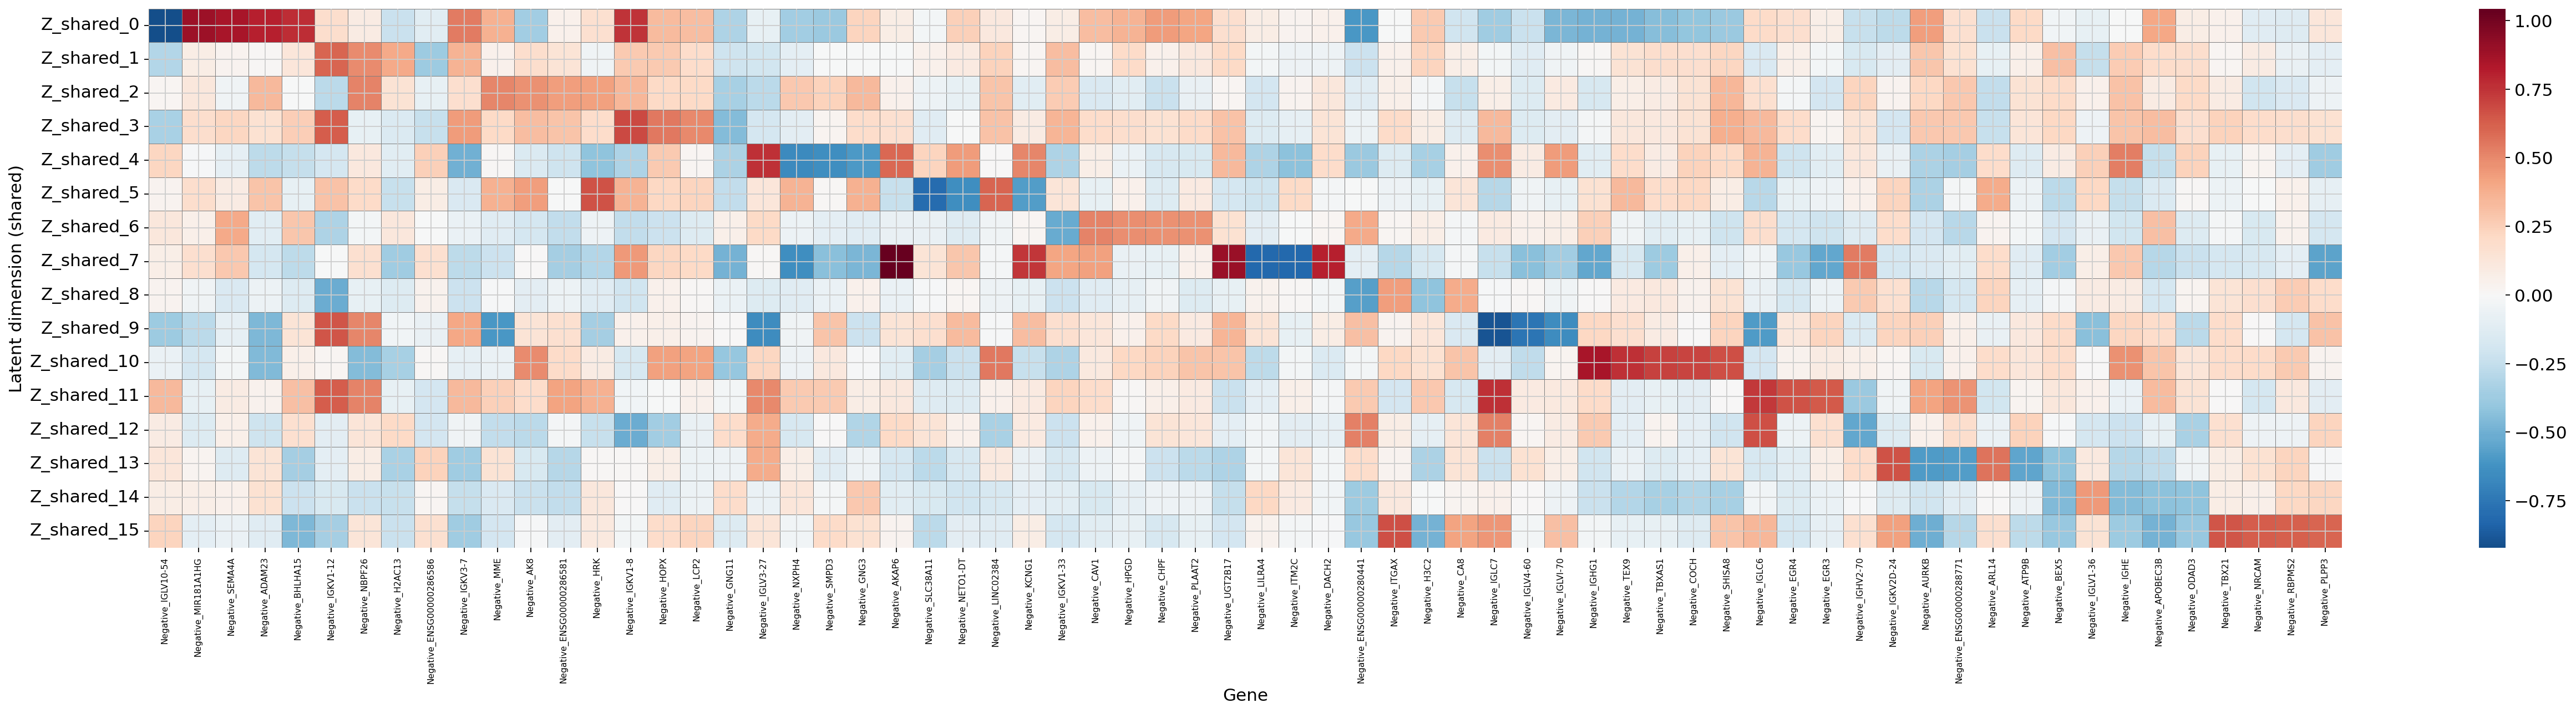

In [35]:
# Heatmap of top-5 genes per dimension (requires seaborn):
ax = spVIPESmulti.pl.heatmap_loadings(model=model_spv, n_top=5)

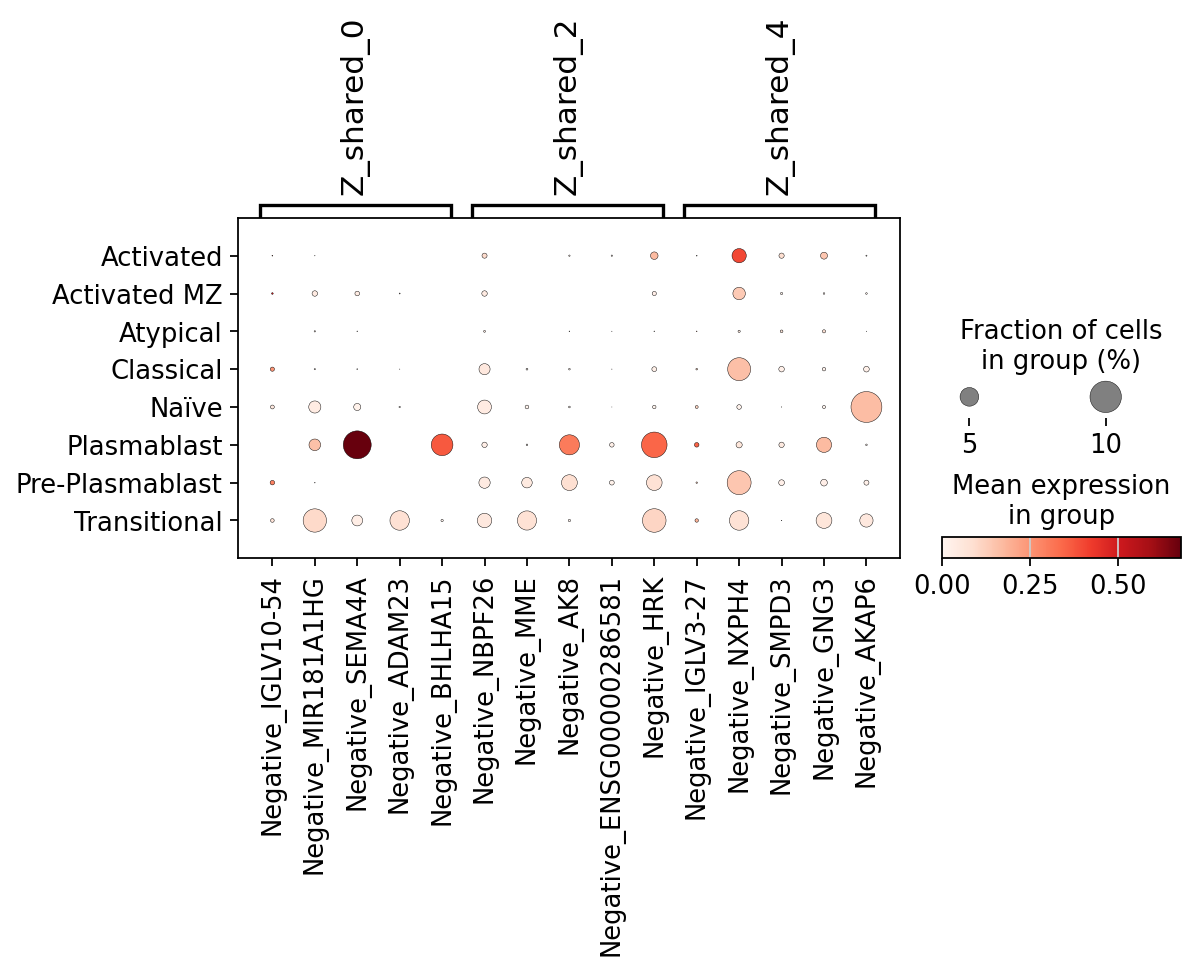

In [38]:
# Scanpy dotplot of selected dimensions:
spVIPESmulti.pl.loadings_dotplot(adata_spv, dims=[0, 2, 4], groupby="cluster_label", model=model_spv)


In [39]:
adata_spv

AnnData object with n_obs × n_vars = 20761 × 10000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'nCount_HTO', 'nFeature_HTO', 'batch', 'cellhashr_id', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_hemo', 'scdblfinder_score', 'scdblfinder_class', 'scran_size_factors', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'clonalProportion', 'clonalFrequency', 'cloneSize', 'barcode', 'IGH', 'cdr3_aa1', 'cdr3_nt1', 'IGLC', 'cdr3_nt2', 'has_bcr', 'NANP', 'NJunction', 'qc_keep', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'seurat_clusters', 'MG_nn_res.0.1', 'MG_res.0.1', 'MG_nn_res.0.2', 'MG_res.0.2', 'MG_nn_res.0.3', 'MG_res.0.3', 'MG_nn_res.0.4', 'MG_res.0.4', 'MG_nn_res.0.5', 'MG_res.0.5', 'MG_nn_res.0.6', 'MG_res.0.6', 'MG_nn_res.0.7', 'MG_res.0.7', 'MG_nn_res.0.8', 'MG_res.0.8', 'MG_nn_res.0.9', 'MG_res.0.9', 'MG_nn_res.1', 'MG_res.1', 'MG_nn_res.1.1', 'MG_res.1.1', 'MG_nn_res.1.2', 'MG_res.1.2', 'MG_nn_res.1.3', 'MG_res.1.3', 

In [41]:
# Copy a single dimension into adata.obs for use as a color key:
spVIPESmulti.utils.score_cells_on_factor(adata_spv, dim_idx=0, obsm_key="X_spvm_shared")

AnnData object with n_obs × n_vars = 20761 × 10000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'nCount_HTO', 'nFeature_HTO', 'batch', 'cellhashr_id', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_hemo', 'scdblfinder_score', 'scdblfinder_class', 'scran_size_factors', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'clonalProportion', 'clonalFrequency', 'cloneSize', 'barcode', 'IGH', 'cdr3_aa1', 'cdr3_nt1', 'IGLC', 'cdr3_nt2', 'has_bcr', 'NANP', 'NJunction', 'qc_keep', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'seurat_clusters', 'MG_nn_res.0.1', 'MG_res.0.1', 'MG_nn_res.0.2', 'MG_res.0.2', 'MG_nn_res.0.3', 'MG_res.0.3', 'MG_nn_res.0.4', 'MG_res.0.4', 'MG_nn_res.0.5', 'MG_res.0.5', 'MG_nn_res.0.6', 'MG_res.0.6', 'MG_nn_res.0.7', 'MG_res.0.7', 'MG_nn_res.0.8', 'MG_res.0.8', 'MG_nn_res.0.9', 'MG_res.0.9', 'MG_nn_res.1', 'MG_res.1', 'MG_nn_res.1.1', 'MG_res.1.1', 'MG_nn_res.1.2', 'MG_res.1.2', 'MG_nn_res.1.3', 'MG_res.1.3', 

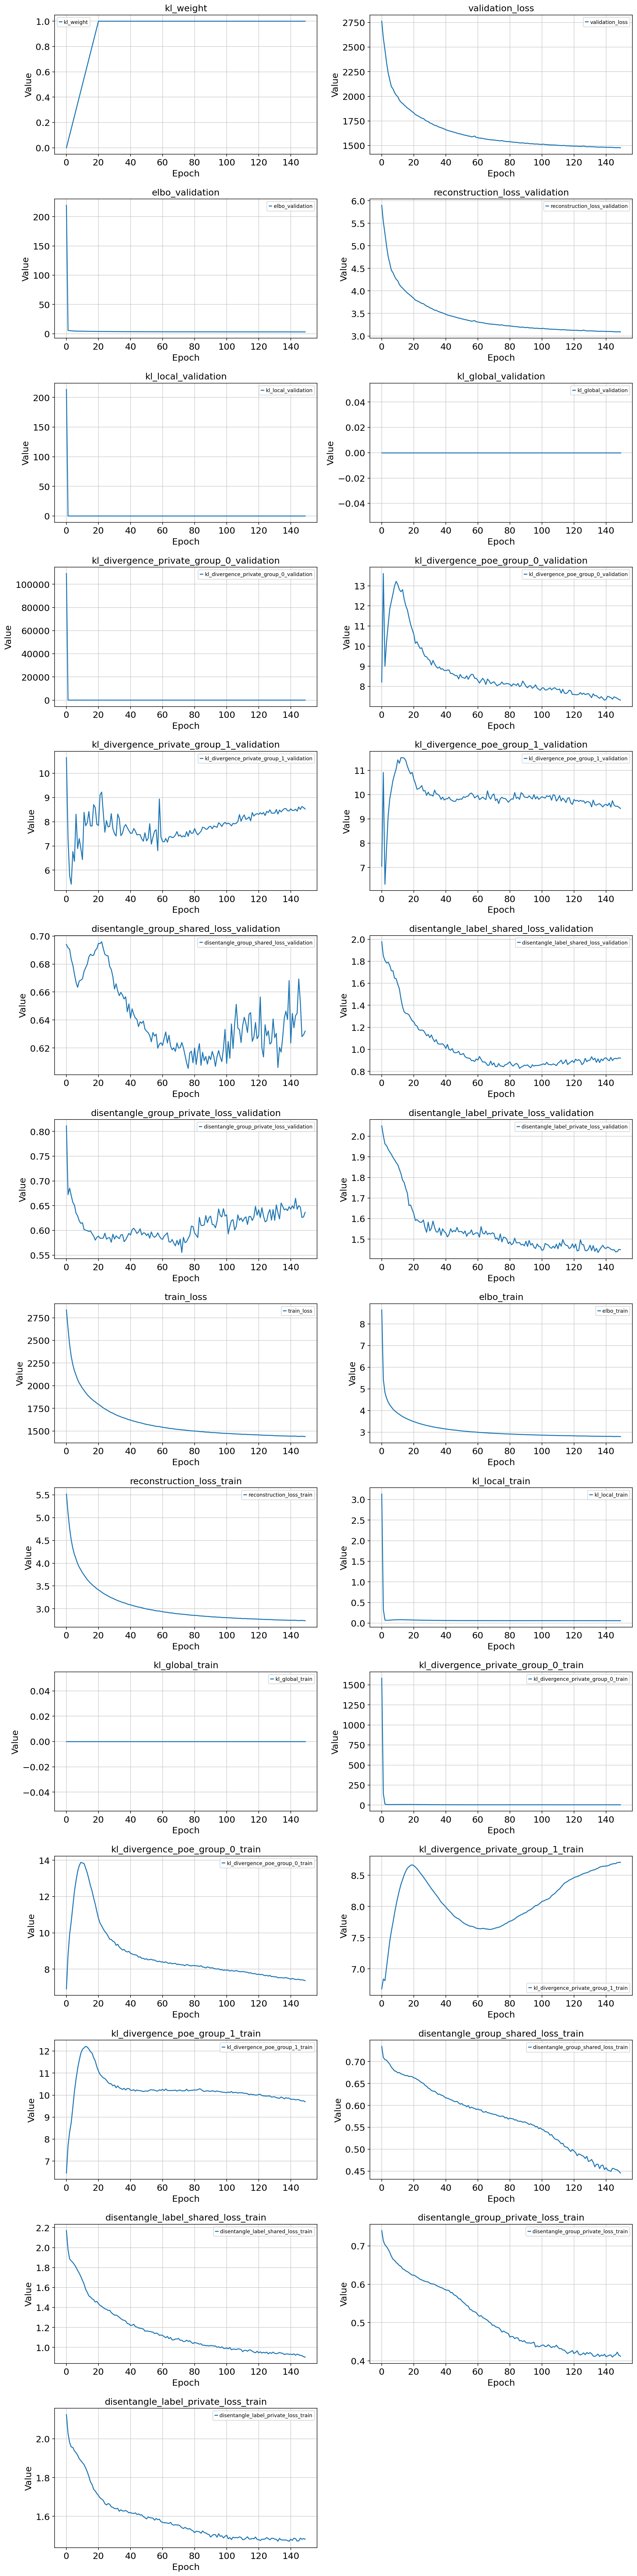

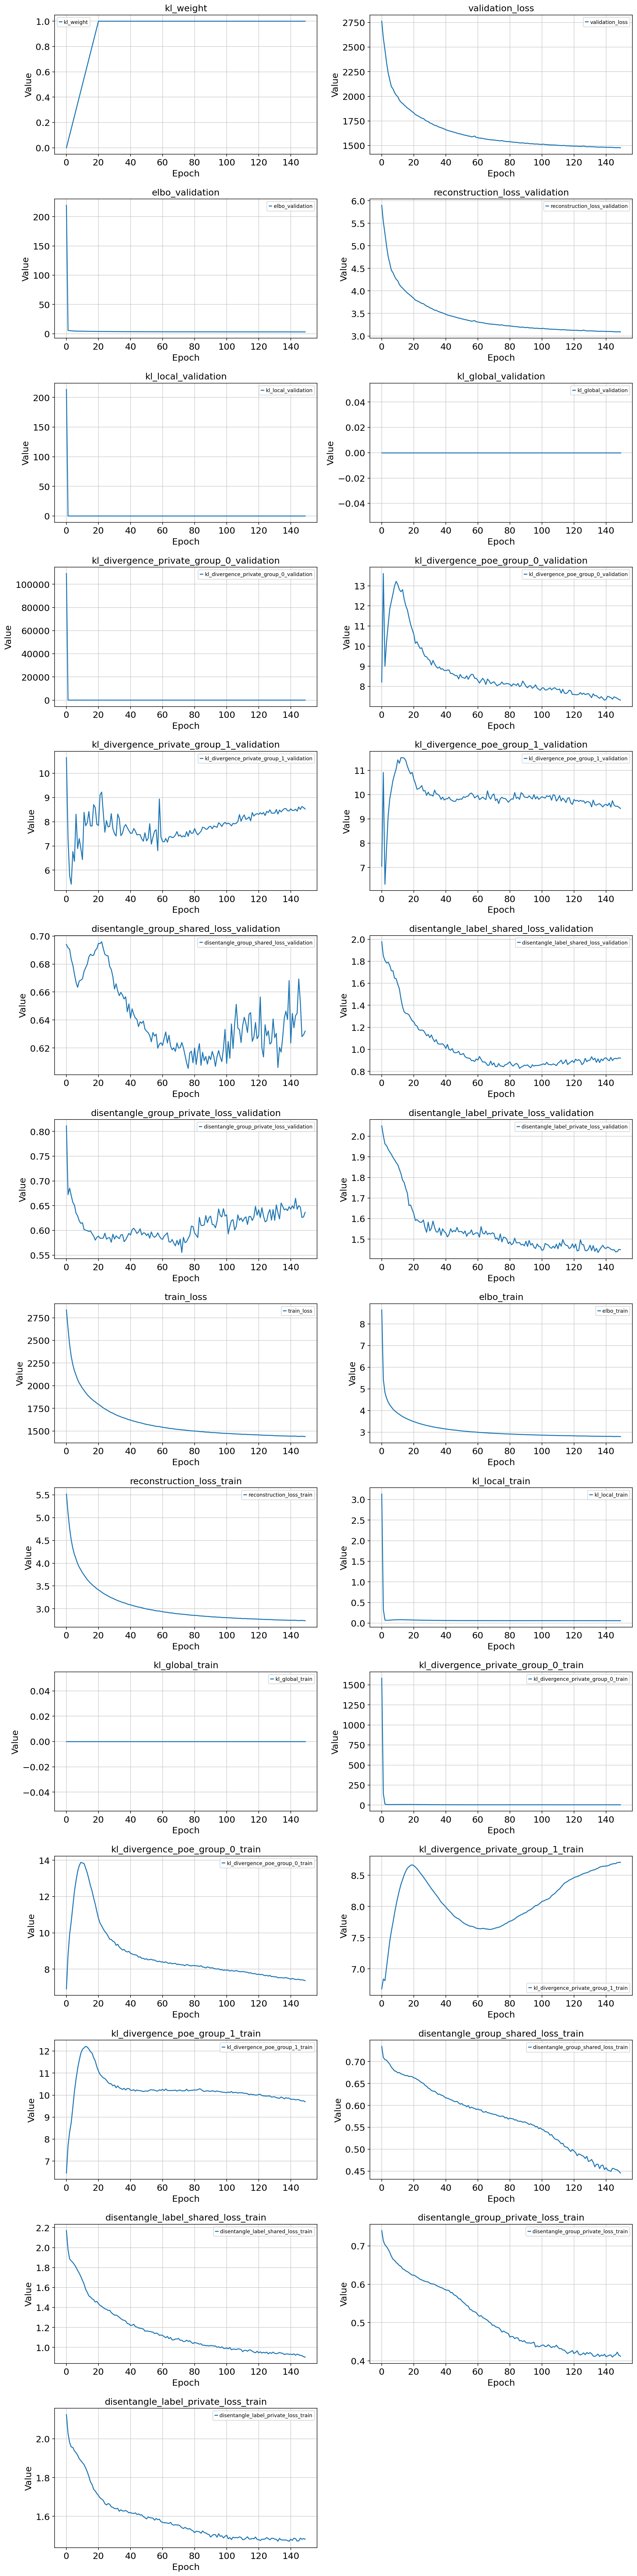

In [47]:
spVIPESmulti.pl.training_curves(model_spv)

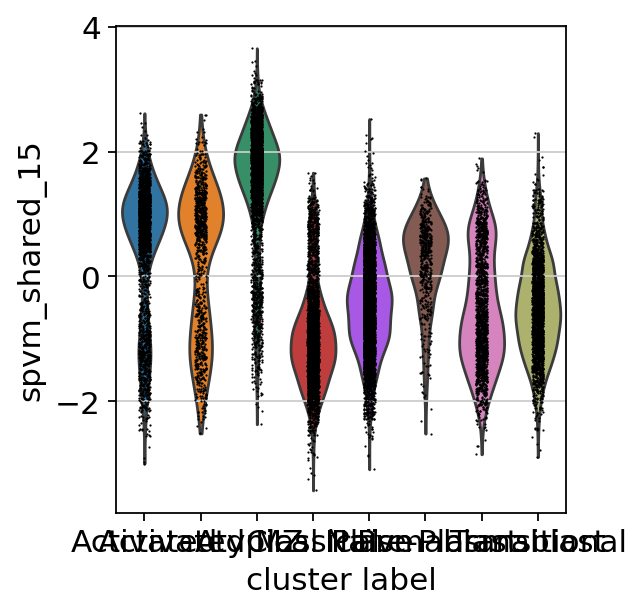

In [49]:
# Violin plot of a specific latent factor:
spVIPESmulti.pl.factor_violin(adata_spv, dim_idx=15, groupby="cluster_label", obsm_key="X_spvm_shared")

In [48]:
from sklearn.metrics import roc_auc_score

shared_key = "X_spVIPESmulti_shared" if "X_spVIPESmulti_shared" in adata_spv.obsm else payload["keys"]["shared"]
target_celltype = "Atypical"

shared = pd.DataFrame(
    adata_spv.obsm[shared_key],
    index=adata_spv.obs_names,
    columns=[f"shared_{i}" for i in range(adata_spv.obsm[shared_key].shape[1])],
)
labels = adata_spv.obs["cluster_label"].astype(str)

rows = []
for celltype in sorted(labels.unique()):
    is_target = (labels == celltype).to_numpy()
    target_n = int(is_target.sum())
    rest_n = int((~is_target).sum())
    if target_n == 0 or rest_n == 0:
        continue

    for dim_name in shared.columns:
        values = shared[dim_name].to_numpy()
        auc = roc_auc_score(is_target, values)
        target_values = values[is_target]
        rest_values = values[~is_target]
        mean_target = float(target_values.mean())
        mean_rest = float(rest_values.mean())
        pooled_sd = float(np.sqrt((target_values.var(ddof=1) + rest_values.var(ddof=1)) / 2))
        cohens_d = 0.0 if pooled_sd == 0 else (mean_target - mean_rest) / pooled_sd
        rows.append(
            {
                "celltype": celltype,
                "dimension": dim_name,
                "dim_idx": int(dim_name.split("_")[-1]),
                "auc": float(auc),
                "specificity_auc": float(max(auc, 1 - auc)),
                "direction": "high_in_target" if mean_target >= mean_rest else "low_in_target",
                "mean_target": mean_target,
                "mean_rest": mean_rest,
                "delta_mean": mean_target - mean_rest,
                "cohens_d": float(cohens_d),
                "abs_cohens_d": float(abs(cohens_d)),
                "target_n": target_n,
                "rest_n": rest_n,
            }
        )

specificity = pd.DataFrame(rows).sort_values(
    ["celltype", "specificity_auc", "abs_cohens_d"],
    ascending=[True, False, False],
)

best_dim_per_celltype = (
    specificity.groupby("celltype", group_keys=False)
    .head(1)
    .loc[:, ["celltype", "dimension", "dim_idx", "specificity_auc", "direction", "cohens_d"]]
    .sort_values("specificity_auc", ascending=False)
)

best_celltype_per_dimension = (
    specificity.sort_values(["dimension", "specificity_auc", "abs_cohens_d"], ascending=[True, False, False])
    .groupby("dimension", group_keys=False)
    .head(1)
    .loc[:, ["dimension", "dim_idx", "celltype", "specificity_auc", "direction", "cohens_d"]]
    .sort_values("dim_idx")
    .reset_index(drop=True)
)

atypical_specificity = (
    specificity.loc[specificity["celltype"] == target_celltype]
    .loc[:, ["dimension", "dim_idx", "specificity_auc", "direction", "delta_mean", "cohens_d"]]
    .head(8)
    .reset_index(drop=True)
)

print(f"Shared latent key: {shared_key}")
print("\nBest shared dimension per cell type:")
print(best_dim_per_celltype.to_string(index=False))
print("\nBest-matching cell type for each shared dimension:")
print(best_celltype_per_dimension.to_string(index=False))
print(f"\nTop shared dimensions distinguishing {target_celltype} vs rest:")
print(atypical_specificity.to_string(index=False))

Shared latent key: X_spVIPESmulti_shared

Best shared dimension per cell type:
       celltype dimension  dim_idx  specificity_auc      direction  cohens_d
    Plasmablast shared_10       10         0.957890 high_in_target  2.541757
       Atypical shared_15       15         0.903941 high_in_target  1.897346
      Classical  shared_0        0         0.885091  low_in_target -1.729240
Pre-Plasmablast  shared_0        0         0.813488  low_in_target -1.283952
      Activated shared_10       10         0.791980 high_in_target  1.133503
   Transitional shared_10       10         0.781903  low_in_target -1.125387
          Naïve  shared_4        4         0.766653 high_in_target  1.038557
   Activated MZ  shared_4        4         0.714725  low_in_target -0.797197

Best-matching cell type for each shared dimension:
dimension  dim_idx        celltype  specificity_auc      direction  cohens_d
 shared_0        0       Classical         0.885091  low_in_target -1.729240
 shared_1        1    

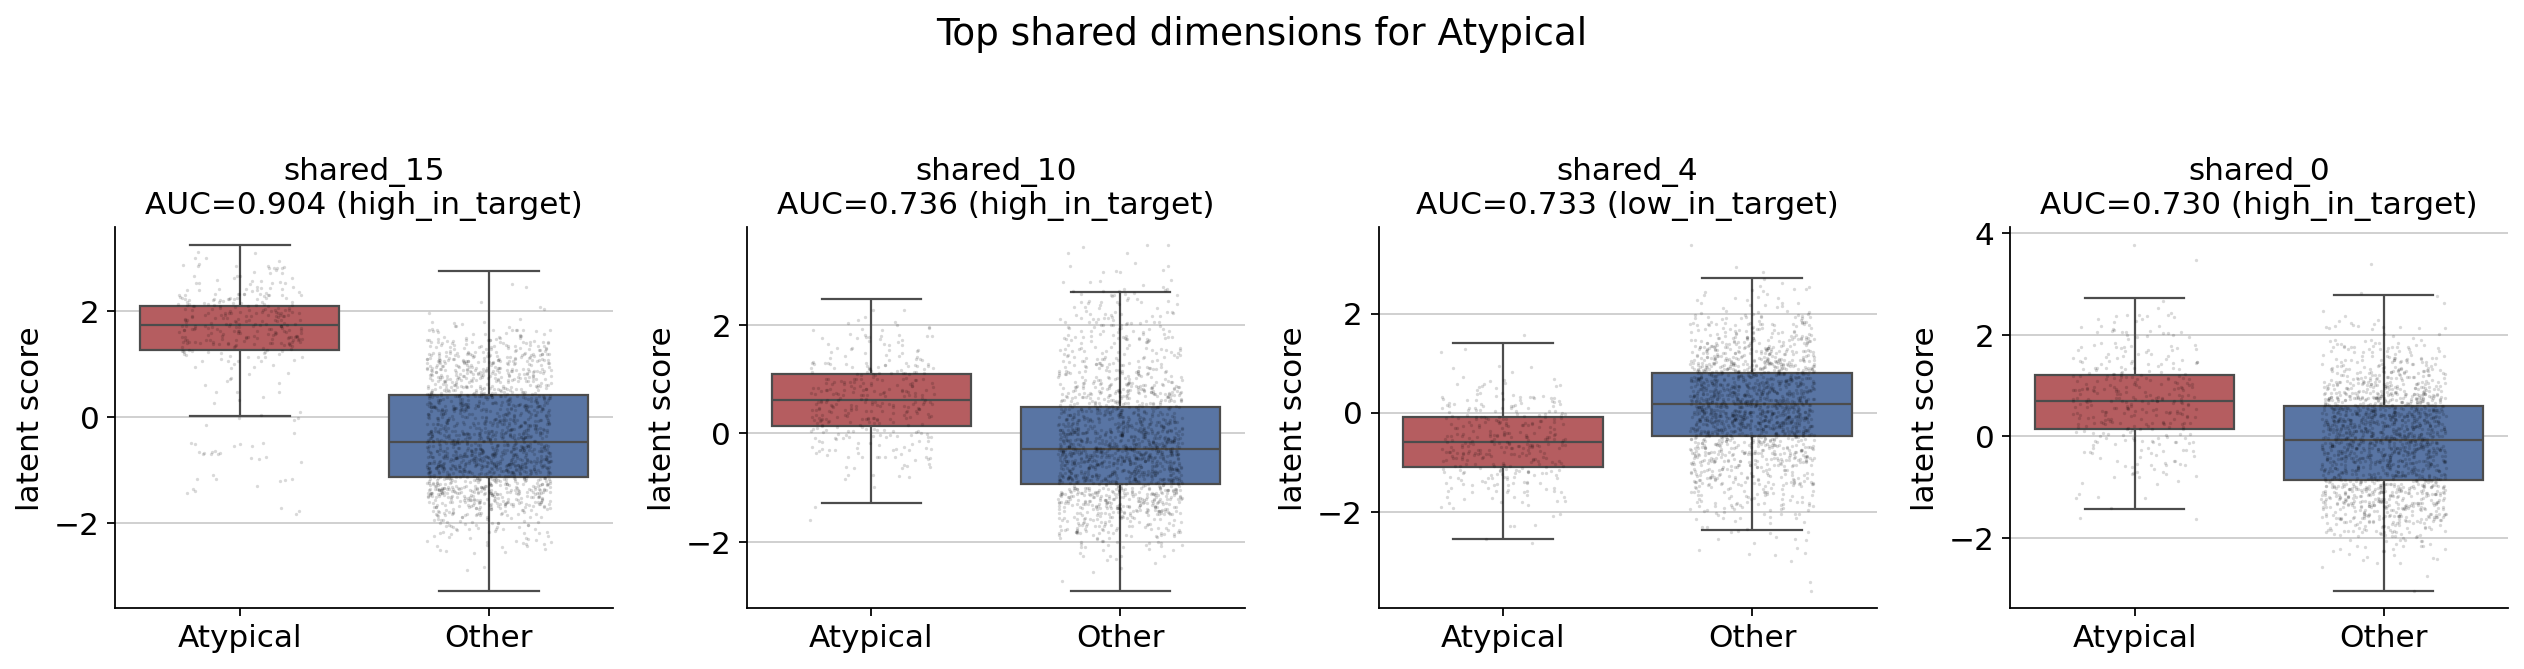

In [45]:
top_dims = atypical_specificity["dimension"].head(4).tolist()
plot_df = shared.loc[:, top_dims].copy()
plot_df["cluster_label"] = labels.to_numpy()
plot_df["is_atypical"] = np.where(plot_df["cluster_label"] == target_celltype, target_celltype, "Other")
plot_df = plot_df.melt(id_vars=["cluster_label", "is_atypical"], var_name="dimension", value_name="score")

fig, axes = plt.subplots(1, len(top_dims), figsize=(4 * len(top_dims), 4), sharey=False)
if len(top_dims) == 1:
    axes = [axes]

for ax, dim_name in zip(axes, top_dims):
    dim_df = plot_df[plot_df["dimension"] == dim_name]
    sns.boxplot(
        data=dim_df,
        x="is_atypical",
        y="score",
        order=[target_celltype, "Other"],
        palette={target_celltype: "#c44e52", "Other": "#4c72b0"},
        ax=ax,
        showfliers=False,
    )
    sns.stripplot(
        data=dim_df.sample(min(len(dim_df), 2000), random_state=0),
        x="is_atypical",
        y="score",
        order=[target_celltype, "Other"],
        color="black",
        alpha=0.15,
        size=1.5,
        jitter=0.25,
        ax=ax,
    )
    direction = atypical_specificity.loc[atypical_specificity["dimension"] == dim_name, "direction"].iat[0]
    auc = atypical_specificity.loc[atypical_specificity["dimension"] == dim_name, "specificity_auc"].iat[0]
    ax.set_title(f"{dim_name}\nAUC={auc:.3f} ({direction})")
    ax.set_xlabel("")
    ax.set_ylabel("latent score")

sns.despine()
plt.suptitle(f"Top shared dimensions for {target_celltype}", y=1.05)
plt.tight_layout()
plt.show()

In [53]:
# Top genes per shared latent dimension:
top = spVIPESmulti.utils.get_top_genes(model=model_spv, n_top=100)
print(top[["dim", "pos_genes"]].to_string(index=False))
top.to_csv("results/top100_shared.csv")

        dim                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [65]:
import decoupler as dc
from scipy.stats import fisher_exact


def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    ranked = p_values[order]
    adjusted = ranked * len(ranked) / np.arange(1, len(ranked) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    out = np.empty_like(adjusted)
    out[order] = np.clip(adjusted, 0, 1)
    return out


loadings = model_spv.get_loadings()
shared_loading_key = next(key for key in loadings if key[1] == "shared")
shared_loadings = loadings[shared_loading_key].copy()
shared15_col = next(col for col in shared_loadings.columns if str(col).endswith("_15"))

shared_loadings.index = (
    pd.Index(shared_loadings.index.astype(str))
    .str.replace(r"^Negative_", "", regex=True)
    .str.upper()
)
shared_loadings = shared_loadings.loc[~shared_loadings.index.duplicated(keep="first")]

top_n_genes = 100
shared15_genes = shared_loadings[shared15_col].nlargest(top_n_genes).index.astype(str)
universe_genes = pd.Index(shared_loadings.index.astype(str)).str.upper()
query_genes = set(shared15_genes) & set(universe_genes)

msigdb = dc.op.resource("MSigDB", organism="human")
selected_collections = ["immunesigdb"]
msigdb = msigdb.loc[msigdb["collection"].isin(selected_collections)].copy()
msigdb["genesymbol"] = msigdb["genesymbol"].astype(str).str.upper()
msigdb = msigdb.loc[msigdb["genesymbol"].isin(universe_genes)].copy()

genesets = (
    msigdb.groupby(["collection", "geneset"], observed=True)["genesymbol"]
    .agg(lambda genes: sorted(set(genes)))
)

rows = []
universe_size = len(set(universe_genes))
query_size = len(query_genes)
for (collection, geneset), gene_list in genesets.items():
    gene_set = set(gene_list)
    overlap = sorted(query_genes & gene_set)
    overlap_n = len(overlap)
    if overlap_n == 0:
        continue
    only_query = query_size - overlap_n
    only_geneset = len(gene_set) - overlap_n
    neither = universe_size - overlap_n - only_query - only_geneset
    odds_ratio, p_value = fisher_exact(
        [[overlap_n, only_query], [only_geneset, neither]],
        alternative="greater",
    )
    rows.append(
        {
            "collection": collection,
            "geneset": geneset,
            "overlap_n": overlap_n,
            "geneset_size": len(gene_set),
            "query_size": query_size,
            "odds_ratio": float(odds_ratio),
            "p_value": float(p_value),
            "overlap_genes": overlap,
        }
    )

shared15_enrichment = pd.DataFrame(rows)
if shared15_enrichment.empty:
    raise ValueError("No ImmuneSigDB overlaps found for shared_15 after removing the Negative_ prefix.")
shared15_enrichment["fdr"] = benjamini_hochberg(shared15_enrichment["p_value"])
shared15_enrichment["neg_log10_fdr"] = -np.log10(shared15_enrichment["fdr"].clip(lower=1e-300))
shared15_enrichment = shared15_enrichment.sort_values(
    ["fdr", "odds_ratio", "overlap_n"],
    ascending=[True, False, False],
).reset_index(drop=True)

print(f"Shared loading key: {shared_loading_key}")
print(f"Shared dimension: {shared15_col}")
print(f"Top positive genes used for ImmuneSigDB enrichment (n={query_size}):")
print(", ".join(sorted(query_genes)[:25]) + (" ..." if query_size > 25 else ""))
print("\nTop ImmuneSigDB terms for shared_15:")
print(shared15_enrichment.loc[:, ["geneset", "overlap_n", "odds_ratio", "fdr"]].head(15).to_string(index=False))

Shared loading key: (0, 'shared')
Shared dimension: Z_shared_15
Top positive genes used for ImmuneSigDB enrichment (n=100):
ADAM15, ADAP1, AMOT, APOD, ARL4D, ATP8A2, BATF, C21ORF91-OT1, CA8, CAMSAP2, CD200R1, CDC42EP3-AS1, CEND1, CST7, CXCR3, DCAF12, DGKG, DHRS9, DUSP15, DUSP8, DYNLRB2-AS1, EFCAB9, ENC1, ENSG00000174171, ENSG00000233785 ...

Top ImmuneSigDB terms for shared_15:
                                                           geneset  overlap_n  odds_ratio      fdr
                                       GSE29618_MONOCYTE_VS_PDC_UP          8    6.676329 0.203987
   GSE21774_CD62L_POS_CD56_BRIGHT_VS_CD62L_NEG_CD56_DIM_NK_CELL_UP          7    6.395208 0.203987
                                  GSE30083_SP3_VS_SP4_THYMOCYTE_DN          7    6.071685 0.203987
              GSE39916_B_CELL_SPLEEN_VS_PLASMA_CELL_BONE_MARROW_DN          7    5.970915 0.203987
           GSE32986_CURDLAN_LOWDOSE_VS_CURDLAN_HIGHDOSE_STIM_DC_DN          7    5.873396 0.203987
                   GSE360

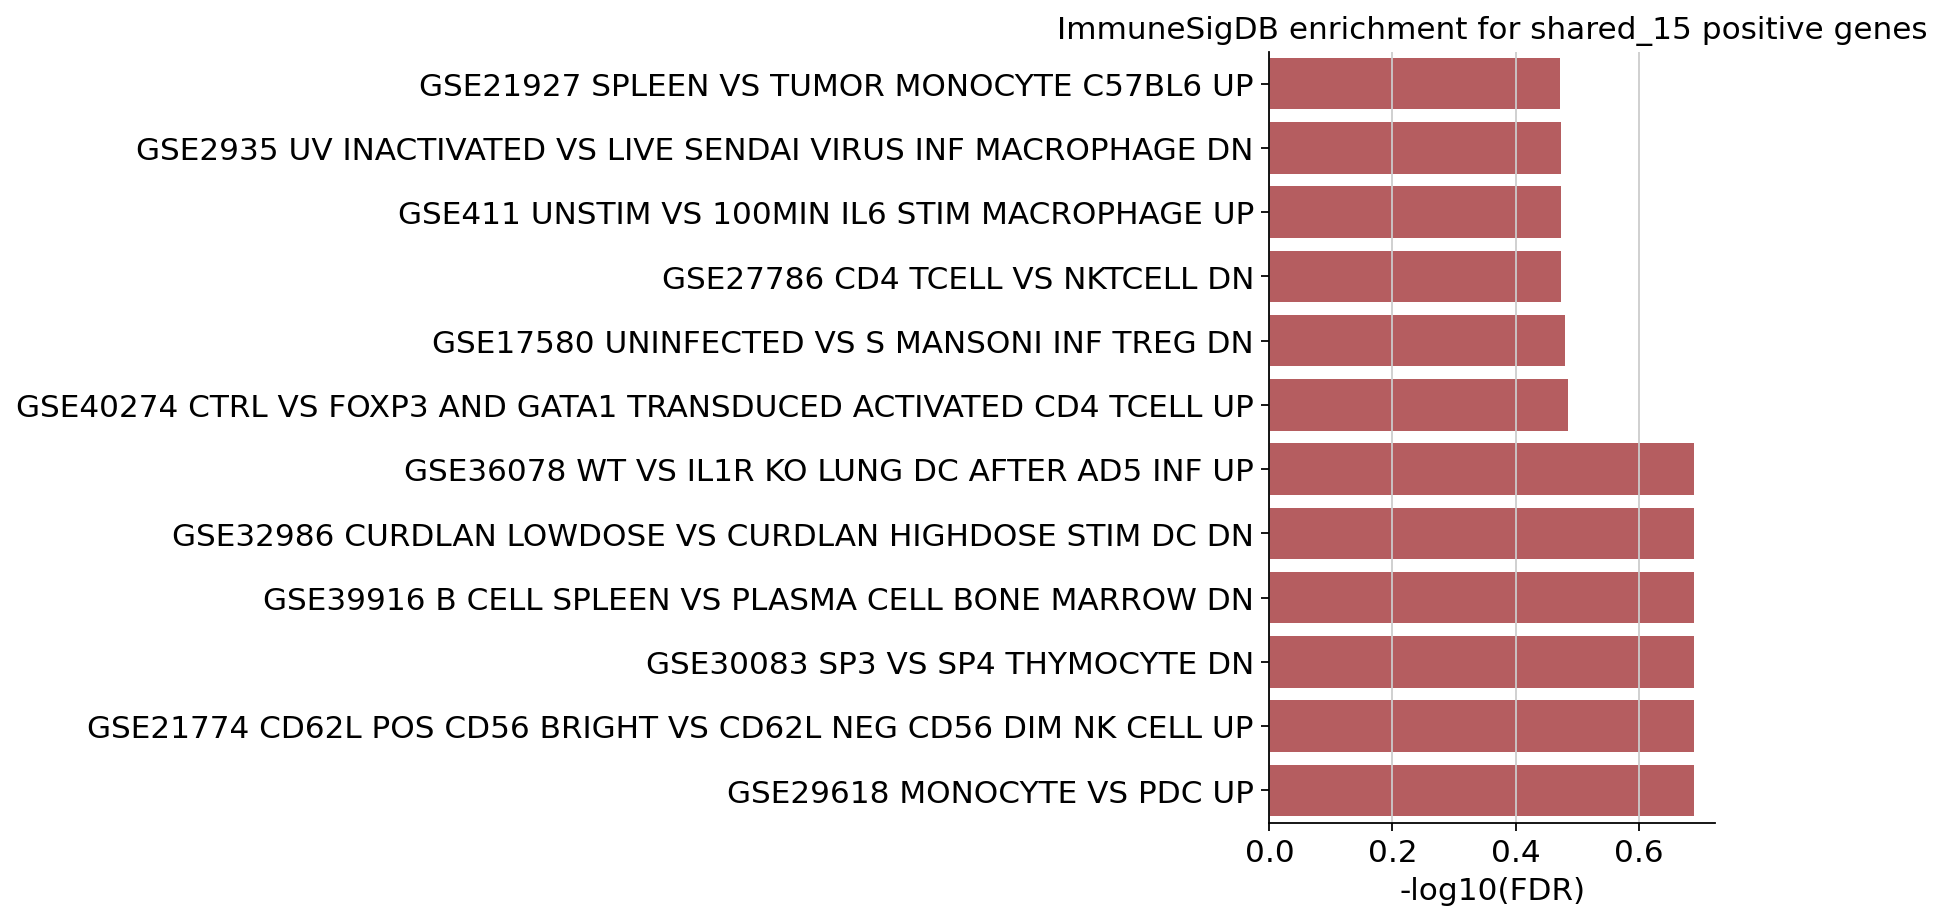

In [66]:
top_terms = shared15_enrichment.head(12).iloc[::-1].copy()
plot_labels = top_terms["geneset"].str.replace("_", " ", regex=False).str.slice(0, 90)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=top_terms,
    x="neg_log10_fdr",
    y=plot_labels,
    color="#c44e52",
    ax=ax,
)
ax.set_xlabel("-log10(FDR)")
ax.set_ylabel("")
ax.set_title("ImmuneSigDB enrichment for shared_15 positive genes")
sns.despine()
plt.tight_layout()
plt.show()

In [61]:
loadings = model_spv.get_loadings()
shared_loading_key = next(key for key in loadings if key[1] == "shared")
shared_loadings = loadings[shared_loading_key].copy()
shared15_col = next(col for col in shared_loadings.columns if str(col).endswith("_15"))
shared15_raw_genes = shared_loadings[shared15_col].nlargest(20).index.astype(str)

msigdb = dc.op.resource("MSigDB", organism="human")
msigdb_genes = set(msigdb["genesymbol"].astype(str).str.upper())

print("Top shared_15 raw gene names:")
print(shared15_raw_genes.tolist())
print("\nDirect overlap:", sum(g.upper() in msigdb_genes for g in shared15_raw_genes))
print("Suffix-stripped overlap:", sum(g.upper().split("_")[0] in msigdb_genes for g in shared15_raw_genes))

Top shared_15 raw gene names:
['Negative_ITGAX', 'Negative_TBX21', 'Negative_NRCAM', 'Negative_RBPMS2', 'Negative_PLPP3', 'Negative_GAS7', 'Negative_RCBTB2', 'Negative_IGLV5-45', 'Negative_SYT1', 'Negative_NKG7', 'Negative_CST7', 'Negative_FRMPD3', 'Negative_SIGLEC6', 'Negative_ARL4D', 'Negative_ADAP1', 'Negative_SMOC2', 'Negative_FGD4', 'Negative_LINC01176', 'Negative_LINC01605', 'Negative_SLC25A29']

Direct overlap: 0
Suffix-stripped overlap: 0


In [68]:
import inspect
import decoupler as dc

print("gsea:", inspect.signature(dc.mt.gsea))
print("ulm:", inspect.signature(dc.mt.ulm))
print("ora:", inspect.signature(dc.mt.ora))

gsea: (data: anndata._core.anndata.AnnData | pandas.core.frame.DataFrame | tuple[numpy.ndarray, numpy.ndarray, numpy.ndarray], net: pandas.core.frame.DataFrame, tmin: int | float = 5, raw: bool = False, empty: bool = True, bsize: int | float = 250000, verbose: bool = False, **kwargs)
ulm: (data: anndata._core.anndata.AnnData | pandas.core.frame.DataFrame | tuple[numpy.ndarray, numpy.ndarray, numpy.ndarray], net: pandas.core.frame.DataFrame, tmin: int | float = 5, raw: bool = False, empty: bool = True, bsize: int | float = 250000, verbose: bool = False, **kwargs)
ora: (data: anndata._core.anndata.AnnData | pandas.core.frame.DataFrame | tuple[numpy.ndarray, numpy.ndarray, numpy.ndarray], net: pandas.core.frame.DataFrame, tmin: int | float = 5, raw: bool = False, empty: bool = True, bsize: int | float = 250000, verbose: bool = False, **kwargs)


In [69]:
msigdb_collections = dc.op.resource("MSigDB", organism="human")["collection"].drop_duplicates().sort_values()
print([collection for collection in msigdb_collections.tolist() if "hallmark" in collection.lower()][:20])

['hallmark']


In [77]:
# New analysis: ranked-list GSEA/ULM for shared_15 using curated B-cell markers and MSigDB Hallmark.

def extract_decoupler_scores(tmp_adata, method):
    score_key = f"score_{method}"
    if hasattr(dc, "pp") and hasattr(dc.pp, "get_obsm"):
        score_adata = dc.pp.get_obsm(tmp_adata, key=score_key)
        score_values = score_adata.X
        if hasattr(score_values, "toarray"):
            score_values = score_values.toarray()
        return pd.DataFrame(
            np.asarray(score_values),
            index=score_adata.obs_names,
            columns=[str(column) for column in score_adata.var_names],
        )
    score_values = tmp_adata.obsm[score_key]
    if hasattr(score_values, "toarray"):
        score_values = score_values.toarray()
    return pd.DataFrame(
        np.asarray(score_values),
        index=tmp_adata.obs_names,
        columns=[str(column) for column in range(np.asarray(score_values).shape[1])],
    )


def run_ranked_decoupler(loadings_series, network, methods=("gsea", "ulm"), tmin=3):
    ranked_df = pd.DataFrame([loadings_series.values], index=[loadings_series.name], columns=loadings_series.index)
    outputs = {}
    for method in methods:
        tmp = ad.AnnData(ranked_df.copy())
        tmp.var_names = ranked_df.columns.astype(str)
        tmp.obs_names = ranked_df.index.astype(str)
        getattr(dc.mt, method)(data=tmp, net=network, tmin=tmin, verbose=False)
        scores = extract_decoupler_scores(tmp, method).T
        scores.columns = [method]
        outputs[method] = scores.sort_values(method, ascending=False)
    return outputs


shared15_ranked = shared_loadings[shared15_col].sort_values(ascending=False)

curated_marker_sets = {
    "atypical_b_cell": ["ITGAX", "TBX21", "FCRL5", "FCRL3", "BATF", "ZEB2", "SOX5", "CXCR3", "SIGLEC6", "CD200R1"],
    "activated_b_cell": ["CD69", "CD86", "IRF4", "HLA-DRA", "HLA-DPA1", "HLA-DPB1", "TNFRSF13B", "CD83"],
    "naive_memory_b_cell": ["MS4A1", "CD79A", "CD79B", "CD22", "BANK1", "HVCN1", "FCER2", "IL4R", "CR2", "TCL1A"],
    "plasma_b_cell": ["XBP1", "MZB1", "JCHAIN", "PRDM1", "SDC1", "DERL3", "TNFRSF17", "IGJ"],
}
curated_network = pd.DataFrame(
    [(source, target) for source, targets in curated_marker_sets.items() for target in targets],
    columns=["source", "target"],
)
curated_network["target"] = curated_network["target"].str.upper()
curated_network = curated_network.loc[curated_network["target"].isin(shared15_ranked.index)].drop_duplicates(["source", "target"]).copy()

hallmark_network = dc.op.hallmark(organism="human")
hallmark_network["target"] = hallmark_network["target"].astype(str).str.upper()
hallmark_network = hallmark_network.loc[hallmark_network["target"].isin(shared15_ranked.index)].drop_duplicates(["source", "target"]).copy()

curated_ranked_scores = run_ranked_decoupler(shared15_ranked, curated_network, methods=("gsea", "ulm"), tmin=3)
hallmark_ranked_scores = run_ranked_decoupler(shared15_ranked, hallmark_network, methods=("gsea", "ulm"), tmin=5)

print(f"Ranked shared_15 gene universe: {shared15_ranked.shape[0]} genes")
print(f"Curated marker programs retained: {curated_network['source'].nunique()}")
print(f"Hallmark programs retained: {hallmark_network['source'].nunique()}")

Ranked shared_15 gene universe: 5000 genes
Curated marker programs retained: 4
Hallmark programs retained: 50


In [79]:
print("Curated marker panel, GSEA:")
print(curated_ranked_scores["gsea"].head(10).to_string())
print("\nCurated marker panel, ULM:")
print(curated_ranked_scores["ulm"].head(10).to_string())

print("\nHallmark, GSEA:")
print(hallmark_ranked_scores["gsea"].head(15).to_string())
print("\nHallmark, ULM:")
print(hallmark_ranked_scores["ulm"].head(15).to_string())

Curated marker panel, GSEA:
                         gsea
atypical_b_cell      2.137239
naive_memory_b_cell -1.067449
activated_b_cell    -1.114628
plasma_b_cell       -1.608653

Curated marker panel, ULM:
                          ulm
atypical_b_cell      6.809558
naive_memory_b_cell -0.725613
activated_b_cell    -1.196470
plasma_b_cell       -2.211532

Hallmark, GSEA:
                                       gsea
UV_RESPONSE_DN                     1.680999
XENOBIOTIC_METABOLISM              1.497864
ANGIOGENESIS                       1.383575
APICAL_JUNCTION                    1.379833
IL2_STAT5_SIGNALING                1.245889
HEDGEHOG_SIGNALING                 1.186659
EPITHELIAL_MESENCHYMAL_TRANSITION  1.181566
WNT_BETA_CATENIN_SIGNALING         1.179468
PI3K_AKT_MTOR_SIGNALING            1.173505
COAGULATION                        1.157348
MYOGENESIS                         1.155570
KRAS_SIGNALING_UP                  1.154612
NOTCH_SIGNALING                    1.143656
ALLOGRAFT_R

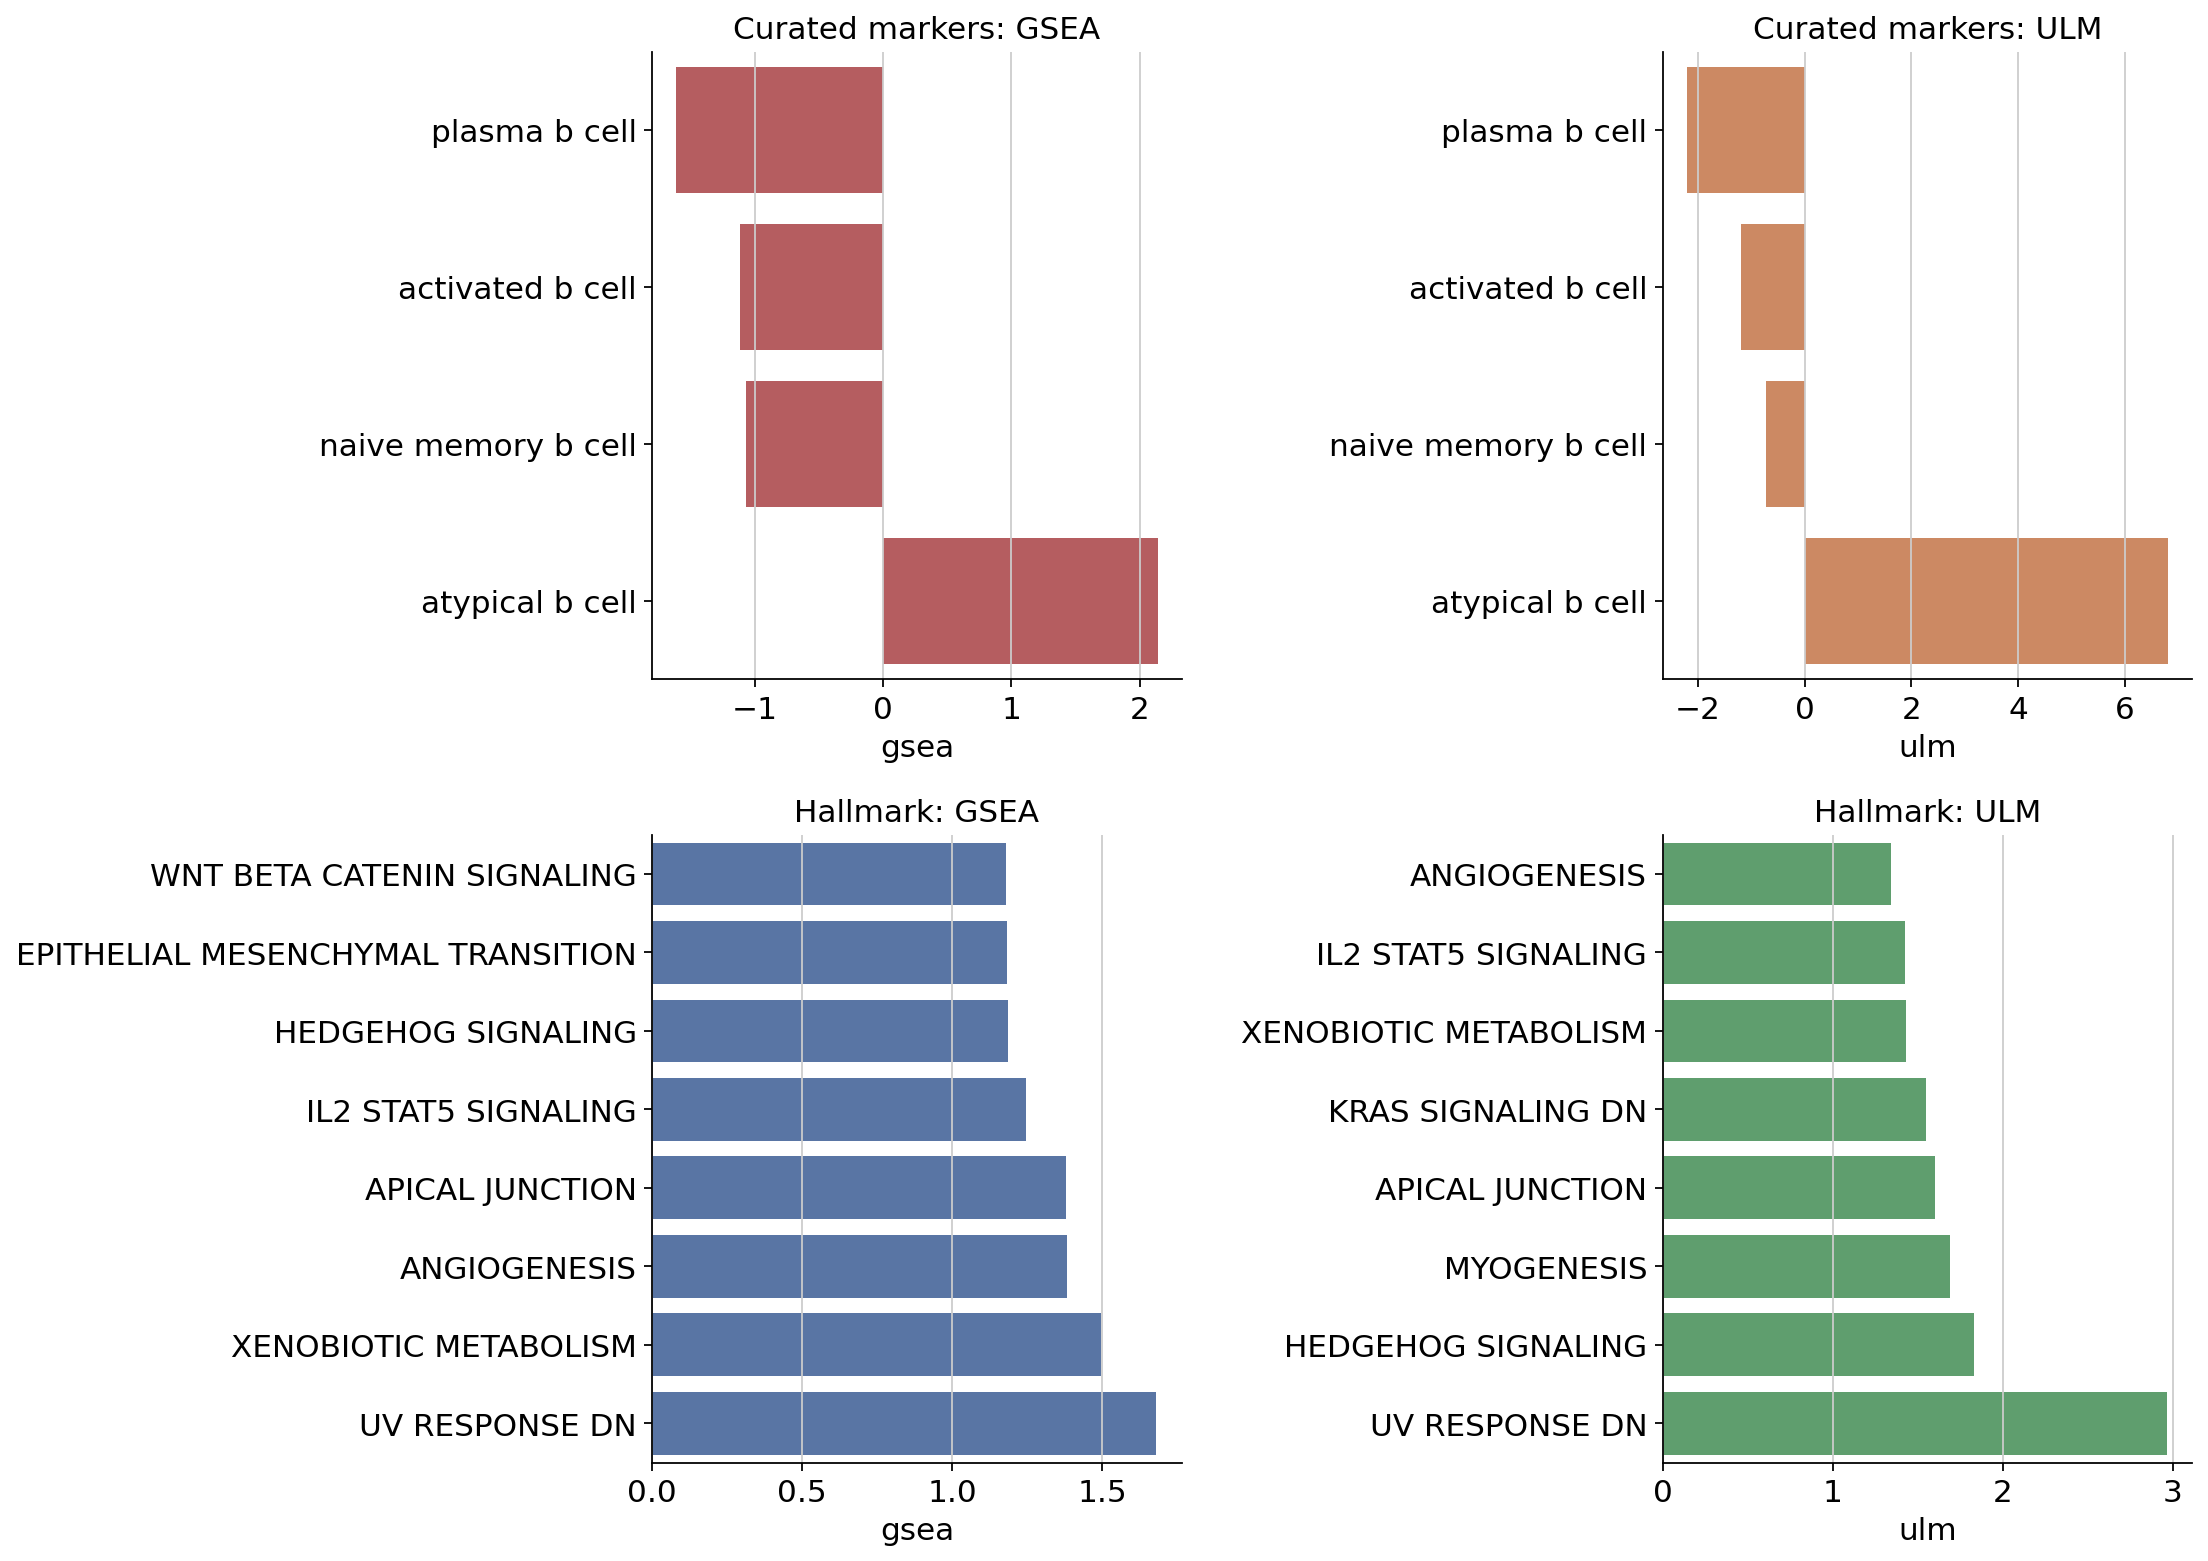

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_specs = [
    (curated_ranked_scores["gsea"].head(4).iloc[::-1], axes[0, 0], "Curated markers: GSEA", "#c44e52"),
    (curated_ranked_scores["ulm"].head(4).iloc[::-1], axes[0, 1], "Curated markers: ULM", "#dd8452"),
    (hallmark_ranked_scores["gsea"].head(8).iloc[::-1], axes[1, 0], "Hallmark: GSEA", "#4c72b0"),
    (hallmark_ranked_scores["ulm"].head(8).iloc[::-1], axes[1, 1], "Hallmark: ULM", "#55a868"),
]

for score_df, ax, title, color in plot_specs:
    label_index = score_df.index.to_series().str.replace("_", " ", regex=False).str.slice(0, 80)
    sns.barplot(x=score_df.iloc[:, 0], y=label_index, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(score_df.columns[0])
    ax.set_ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

In [74]:
# New analysis: transcription factor scoring for shared_15 using CollecTRI + ULM.
loadings = model_spv.get_loadings()
shared_loading_key = next(key for key in loadings if key[1] == "shared")
shared_loadings_tf = loadings[shared_loading_key].copy()
shared15_col_tf = next(col for col in shared_loadings_tf.columns if str(col).endswith("_15"))

shared_loadings_tf.index = (
    pd.Index(shared_loadings_tf.index.astype(str))
    .str.replace(r"^Negative_", "", regex=True)
    .str.upper()
)
shared15_ranked_tf = (
    shared_loadings_tf.groupby(shared_loadings_tf.index)[shared15_col_tf]
    .max()
    .sort_values(ascending=False)
)

shared15_tf_data = shared15_ranked_tf.to_frame().T
shared15_tf_data.index = ["shared15_loading"]

collectri = dc.op.collectri(organism="human")
collectri["target"] = collectri["target"].astype(str).str.upper()
collectri = collectri.loc[:, ["source", "target", "weight"]]
collectri = collectri.loc[collectri["target"].isin(shared15_ranked_tf.index)].drop_duplicates(["source", "target"]).copy()

shared15_tf_acts, shared15_tf_padj = dc.mt.ulm(data=shared15_tf_data, net=collectri)
shared15_tf_summary = pd.DataFrame(
    {
        "ulm_score": shared15_tf_acts.loc["shared15_loading"],
        "padj": shared15_tf_padj.loc["shared15_loading"],
    }
).sort_values("ulm_score", ascending=False)
shared15_tf_summary["neg_log10_padj"] = -np.log10(shared15_tf_summary["padj"].clip(lower=1e-300))
shared15_tf_significant = shared15_tf_summary.loc[shared15_tf_summary["padj"] < 0.05].copy()

print(f"Shared loading key: {shared_loading_key}")
print(f"Shared dimension: {shared15_col_tf}")
print(f"CollecTRI TFs retained: {collectri['source'].nunique()}")
print(f"CollecTRI edges retained: {collectri.shape[0]}")
print("\nTop positive TF activities for shared_15:")
print(shared15_tf_summary.head(15).to_string())
print("\nTop negative TF activities for shared_15:")
print(shared15_tf_summary.tail(15).sort_values("ulm_score").to_string())
print(f"\nSignificant TFs at padj < 0.05: {shared15_tf_significant.shape[0]}")

Shared loading key: (0, 'shared')
Shared dimension: Z_shared_15
CollecTRI TFs retained: 938
CollecTRI edges retained: 10935

Top positive TF activities for shared_15:
         ulm_score      padj  neg_log10_padj
SOX10     2.482801  0.843035        0.074154
BARX2     2.482291  0.843035        0.074154
TBX21     2.438952  0.843035        0.074154
HTATIP2   2.315329  0.843035        0.074154
GATA3     2.196626  0.843035        0.074154
STAT3     2.195287  0.843035        0.074154
NKX2-5    2.128827  0.843035        0.074154
FOXC2     2.097286  0.843035        0.074154
HNF1B     2.097241  0.843035        0.074154
MAF       2.096994  0.843035        0.074154
GATA4     2.017623  0.925819        0.033474
NFIX      2.014773  0.925819        0.033474
CEBPZ     1.969073  0.982330        0.007743
STAT1     1.943653  0.985357        0.006406
NR2F1     1.908024  0.985357        0.006406

Top negative TF activities for shared_15:
        ulm_score      padj  neg_log10_padj
SRSF2   -3.024404  0.84303

In [75]:
tf_focus = [tf for tf in ["PAX5", "EBF1", "RFX5", "RFXAP", "RFXANK", "TBX21", "BATF", "IRF4", "PRDM1", "BCL6"] if tf in shared15_tf_summary.index]
if tf_focus:
    print("Selected B-cell and atypical-B-cell TFs:")
    print(shared15_tf_summary.loc[tf_focus].sort_values("ulm_score", ascending=False).to_string())
else:
    print("None of the selected TFs were retained in the CollecTRI summary.")

Selected B-cell and atypical-B-cell TFs:
        ulm_score      padj  neg_log10_padj
TBX21    2.438952  0.843035        0.074154
EBF1     1.121917  0.985357        0.006406
BATF     0.779083  0.985357        0.006406
IRF4     0.709620  0.985357        0.006406
BCL6     0.275983  0.985357        0.006406
RFXANK   0.086571  0.985357        0.006406
PAX5    -0.378554  0.985357        0.006406
RFXAP   -0.482738  0.985357        0.006406
RFX5    -1.004419  0.985357        0.006406
PRDM1   -1.290643  0.985357        0.006406


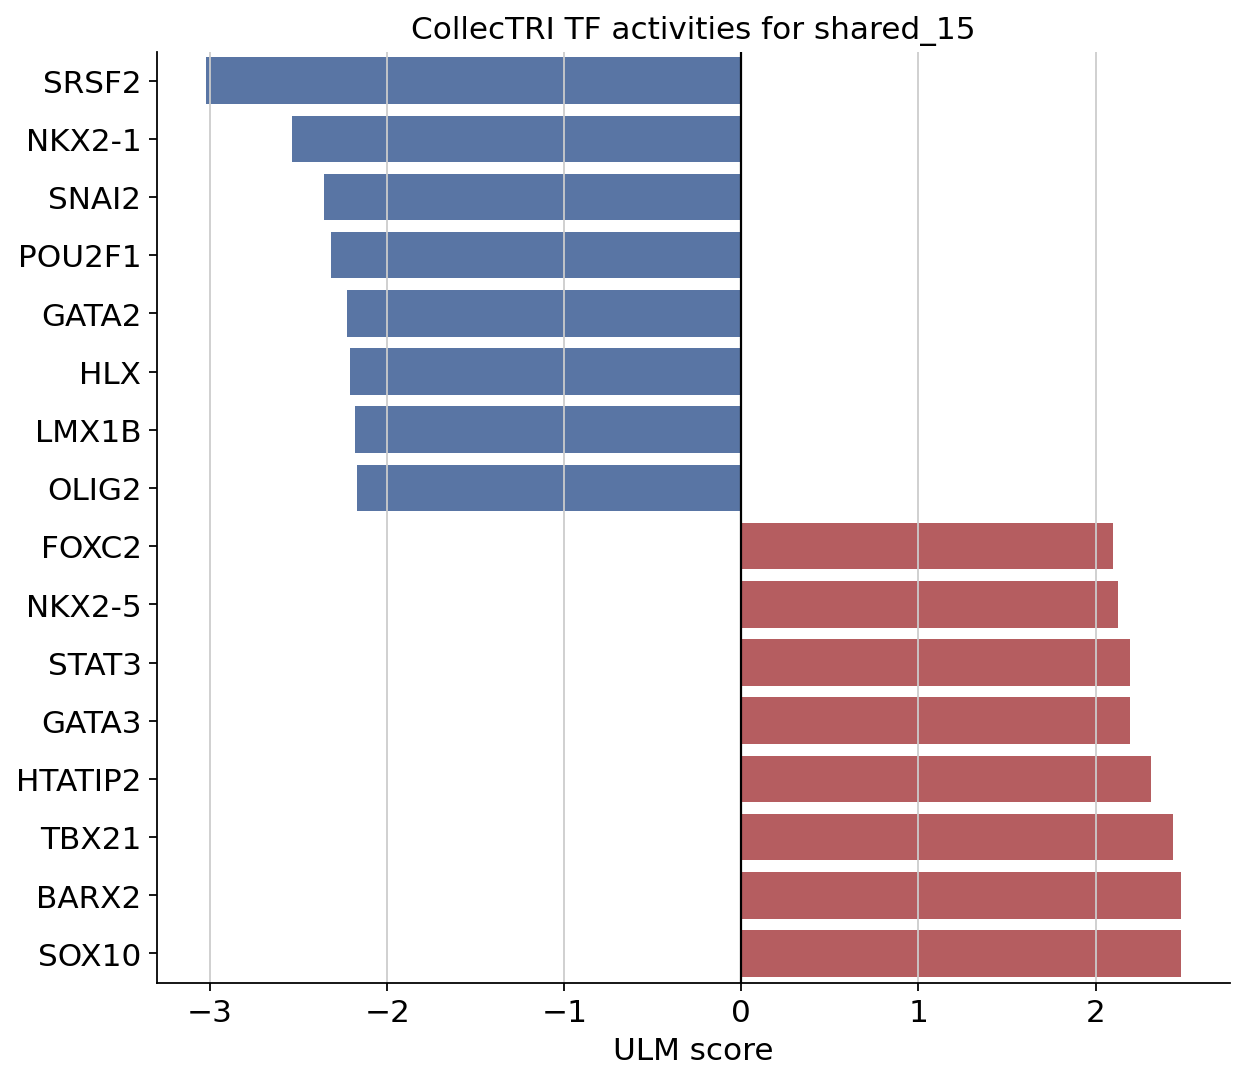

In [76]:
top_tf_plot = pd.concat([
    shared15_tf_summary.head(8),
    shared15_tf_summary.tail(8),
]).drop_duplicates().sort_values("ulm_score")
plot_labels = top_tf_plot.index.to_series().str.slice(0, 40)
colors = np.where(top_tf_plot["ulm_score"] >= 0, "#c44e52", "#4c72b0")

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(x=top_tf_plot["ulm_score"], y=plot_labels, palette=colors, ax=ax)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("ULM score")
ax.set_ylabel("")
ax.set_title("CollecTRI TF activities for shared_15")
sns.despine()
plt.tight_layout()
plt.show()

In [89]:
# New analysis: DoRothEA and PROGENY with ULM + MLM + consensus on shared_15 ranked loadings.

def prepare_network_for_ranked_input(network, genes, require_weight=True):
    network = network.copy()
    network["target"] = network["target"].astype(str).str.upper()
    if require_weight and "weight" not in network.columns:
        network["weight"] = 1.0
    keep_cols = ["source", "target"] + (["weight"] if "weight" in network.columns else [])
    network = network.loc[:, keep_cols]
    network = network.loc[network["target"].isin(genes)].drop_duplicates(["source", "target"]).copy()
    return network


def run_ulm_mlm_consensus(data_df, network, tmin):
    ulm_acts, ulm_padj = dc.mt.ulm(data=data_df, net=network, tmin=tmin, verbose=False)
    mlm_acts, mlm_padj = dc.mt.mlm(data=data_df, net=network, tmin=tmin, verbose=False)

    consensus_payload = {
        "score_ulm": ulm_acts,
        "score_mlm": mlm_acts,
    }
    consensus_acts, consensus_padj = dc.mt.consensus(result=consensus_payload)

    return {
        "ulm_acts": ulm_acts,
        "ulm_padj": ulm_padj,
        "mlm_acts": mlm_acts,
        "mlm_padj": mlm_padj,
        "consensus_acts": consensus_acts,
        "consensus_padj": consensus_padj,
    }


def summarize_method_outputs(result_dict, sample_name):
    summary = pd.DataFrame(
        {
            "ulm": result_dict["ulm_acts"].loc[sample_name],
            "mlm": result_dict["mlm_acts"].loc[sample_name],
            "consensus": result_dict["consensus_acts"].loc[sample_name],
            "consensus_padj": result_dict["consensus_padj"].loc[sample_name],
        }
    )
    summary["neg_log10_consensus_padj"] = -np.log10(summary["consensus_padj"].clip(lower=1e-300))
    return summary.sort_values("consensus", ascending=False)


shared15_ranked_methods = shared15_ranked_tf.copy()
shared15_methods_data = shared15_ranked_methods.to_frame().T
sample_name = "shared15_loading"
shared15_methods_data.index = [sample_name]

# DoRothEA TF network
try:
    dorothea_raw = dc.op.dorothea(organism="human")
    if "confidence" in dorothea_raw.columns:
        dorothea_raw = dorothea_raw.loc[dorothea_raw["confidence"].isin(["A", "B", "C"])].copy()
    dorothea_network = prepare_network_for_ranked_input(dorothea_raw, set(shared15_ranked_methods.index), require_weight=True)
    dorothea_results = run_ulm_mlm_consensus(shared15_methods_data, dorothea_network, tmin=5)
    dorothea_summary = summarize_method_outputs(dorothea_results, sample_name)
    dorothea_ok = True
except Exception as exc:
    dorothea_ok = False
    dorothea_error = exc

# PROGENy pathway network
progeny_raw = dc.op.progeny(organism="human")
progeny_network = prepare_network_for_ranked_input(progeny_raw, set(shared15_ranked_methods.index), require_weight=True)
progeny_results = run_ulm_mlm_consensus(shared15_methods_data, progeny_network, tmin=5)
progeny_summary = summarize_method_outputs(progeny_results, sample_name)

print(f"Shared_15 ranked genes used: {shared15_ranked_methods.shape[0]}")
if dorothea_ok:
    print(f"DoRothEA TFs retained: {dorothea_network['source'].nunique()} | edges: {dorothea_network.shape[0]}")
    print("\nTop DoRothEA TFs by consensus:")
    print(dorothea_summary.head(12).to_string())
else:
    print(f"DoRothEA analysis failed: {dorothea_error}")

print(f"\nPROGENy pathways retained: {progeny_network['source'].nunique()} | edges: {progeny_network.shape[0]}")
print("\nTop PROGENY pathways by consensus:")
print(progeny_summary.head(12).to_string())

Shared_15 ranked genes used: 5000
DoRothEA TFs retained: 340 | edges: 9267

Top DoRothEA TFs by consensus:
              ulm       mlm  consensus  consensus_padj  neg_log10_consensus_padj
SIX2     2.371150  2.605451   2.363999        0.980999                  0.008332
SOX10    2.434513  2.402234   2.288670        0.980999                  0.008332
TBX21    2.372383  2.144847   2.130727        0.980999                  0.008332
SPI1     3.227873  1.399498   2.128100        0.980999                  0.008332
LEF1     2.598808  1.621593   1.964556        0.992102                  0.003444
SP1      2.590703  1.588013   1.943950        0.992102                  0.003444
MYOD1    1.809508  2.211229   1.917209        0.992102                  0.003444
ONECUT1  2.192593  1.638185   1.794569        0.992102                  0.003444
CLOCK    2.214815  1.511962   1.740255        0.992102                  0.003444
ZNF263   1.476462  2.144313   1.736968        0.992102                  0.003444
ST

In [92]:
if dorothea_ok:
    dorothea_focus = [tf for tf in ["TBX21", "BATF", "IRF4", "PAX5", "RFX5", "PRDM1", "BCL6"] if tf in dorothea_summary.index]
    if dorothea_focus:
        print("DoRothEA focus TFs:")
        print(dorothea_summary.loc[dorothea_focus].sort_values("consensus", ascending=False).to_string())
    else:
        print("None of the focus TFs were retained in DoRothEA summary.")
else:
    print("Skipping DoRothEA focus table due to DoRothEA run failure.")

DoRothEA focus TFs:
            ulm       mlm  consensus  consensus_padj  neg_log10_consensus_padj
TBX21  2.372383  2.144847   2.130727        0.980999                  0.008332
BATF   1.432334  0.186815   0.723912        0.992102                  0.003444
BCL6   0.580302  0.496659   0.506985        0.992102                  0.003444
IRF4   0.559672  0.195103   0.344846        0.992102                  0.003444
PAX5   0.588667 -0.481590  -0.000137        0.999891                  0.000048
RFX5  -0.409647 -0.293145  -0.426931        0.992102                  0.003444
PRDM1 -0.731903 -1.011734  -1.024897        0.992102                  0.003444


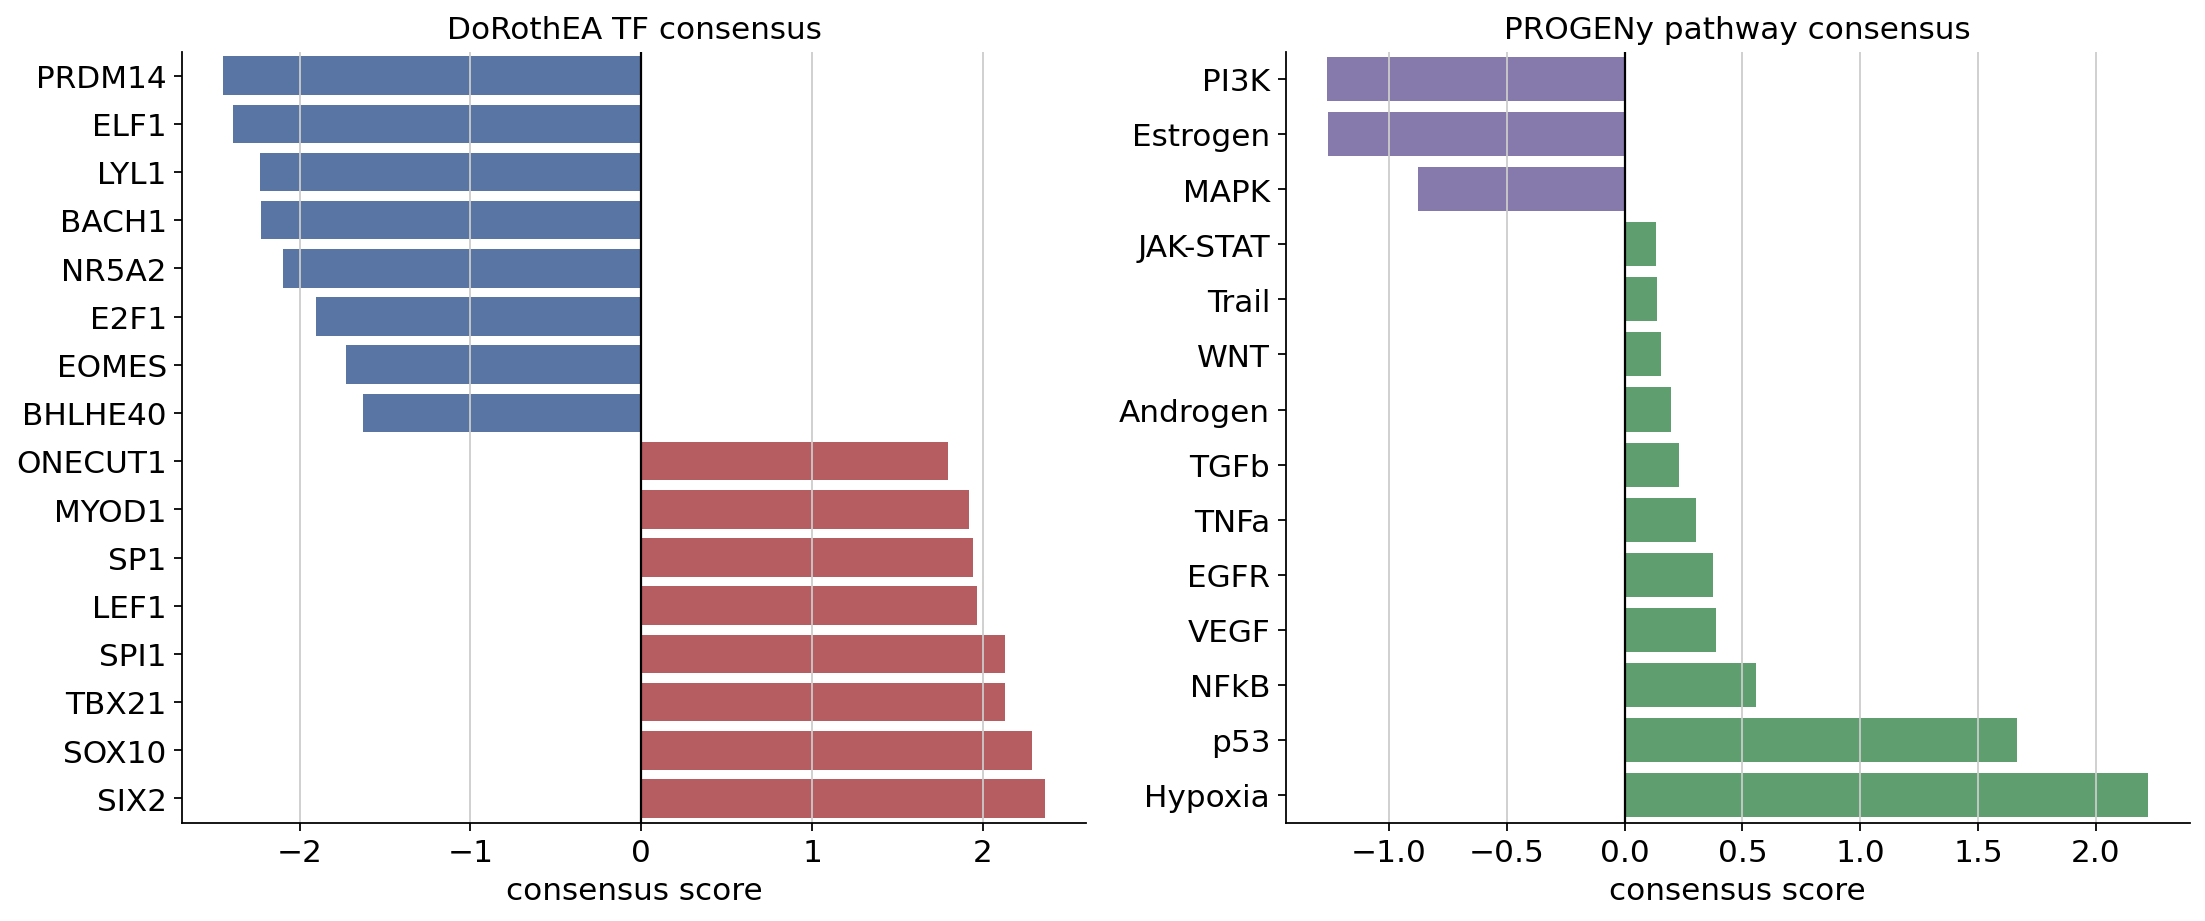

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if dorothea_ok:
    dorothea_plot = pd.concat([dorothea_summary.head(8), dorothea_summary.tail(8)]).drop_duplicates().sort_values("consensus")
    dorothea_labels = dorothea_plot.index.to_series().str.slice(0, 40)
    dorothea_colors = np.where(dorothea_plot["consensus"] >= 0, "#c44e52", "#4c72b0")
    sns.barplot(x=dorothea_plot["consensus"], y=dorothea_labels, palette=dorothea_colors, ax=axes[0])
    axes[0].axvline(0, color="black", linewidth=1)
    axes[0].set_title("DoRothEA TF consensus")
    axes[0].set_xlabel("consensus score")
    axes[0].set_ylabel("")
else:
    axes[0].text(0.5, 0.5, "DoRothEA failed", ha="center", va="center")
    axes[0].set_title("DoRothEA TF consensus")
    axes[0].set_axis_off()

progeny_plot = pd.concat([progeny_summary.head(7), progeny_summary.tail(7)]).drop_duplicates().sort_values("consensus")
progeny_labels = progeny_plot.index.to_series().str.replace("_", " ", regex=False).str.slice(0, 40)
progeny_colors = np.where(progeny_plot["consensus"] >= 0, "#55a868", "#8172b3")
sns.barplot(x=progeny_plot["consensus"], y=progeny_labels, palette=progeny_colors, ax=axes[1])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("PROGENy pathway consensus")
axes[1].set_xlabel("consensus score")
axes[1].set_ylabel("")

sns.despine()
plt.tight_layout()
plt.show()